# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [2]:
# Q1
import pandas as pd
import numpy as np

df = pd.read_csv('/pierce_county_house_sales.csv')
df['sale_date'] = pd.to_datetime(df['sale_date']).dt.date
df.head()

,sale_date,sale_price,house_square_feet,attic_finished_square_feet,basement_square_feet,attached_garage_square_feet,detached_garage_square_feet,fireplaces,hvac_description,exterior,interior,stories,roof_cover,year_built,bedrooms,bathrooms,waterfront_type,view_quality,utility_sewer
0,2020-01-02,380000,2157,0,0,528,0,0,Warm and Cool Air Zone,Frame Siding,Drywall,2,Composition Shingle,1993,3,3,NaN,NaN,SEWER/SEPTIC INSTALLED
1,2020-01-02,383000,2238,0,0,396,0,0,Forced Air,Frame Siding,Drywall,2,Composition Shingle,2017,4,3,NaN,NaN,SEWER/SEPTIC INSTALLED
2,2020-01-01,419900,1452,0,0,0,0,1,Forced Air,Frame Siding,Drywall,1,Built Up Rock,1965,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED
3,2020-01-02,251660,832,0,0,0,0,0,Forced Air,Frame Vinyl,Drywall,1,Composition Shingle,1919,2,1,NaN,NaN,SEWER/SEPTIC INSTALLED
4,2020-01-02,500000,1780,0,384,484,0,1,Forced Air,Frame Siding,Drywall,1,Composition Shingle,1955,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED


In [3]:
# Q2
df['log_sale_price'] = np.log(df['sale_price'])
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [4]:
# Q3
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['sale_price', 'log_sale_price'])
y = df_encoded['log_sale_price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# Q4: My best simple model uses year, sqft, garage sqft, basement sqft.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

features_list = [
    ['house_square_feet'],
    ['year_built', 'house_square_feet', 'bedrooms', 'bathrooms', 'stories'],
    ['year_built', 'house_square_feet', 'attached_garage_square_feet', 'basement_square_feet']
]

for i, features in enumerate(features_list):
    model = LinearRegression()
    model.fit(X_train[features], y_train)

    y_test_pred = model.predict(X_test[features])
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2_test = r2_score(y_test, y_test_pred)

    print(f"Model {i+1} using features {features}")
    print(f"Test RMSE: {rmse_test:.4f}, Test R²: {r2_test:.4f}\n")

Model 1 using features ['house_square_feet']
Test RMSE: 0.3411, Test R²: 0.3597

Model 2 using features ['year_built', 'house_square_feet', 'bedrooms', 'bathrooms', 'stories']
Test RMSE: 0.3338, Test R²: 0.3866

Model 3 using features ['year_built', 'house_square_feet', 'attached_garage_square_feet', 'basement_square_feet']
Test RMSE: 0.3254, Test R²: 0.4171



Train RMSE: 0.3027, Train R²: 0.4958
Test RMSE: 0.3079, Test R²: 0.4781


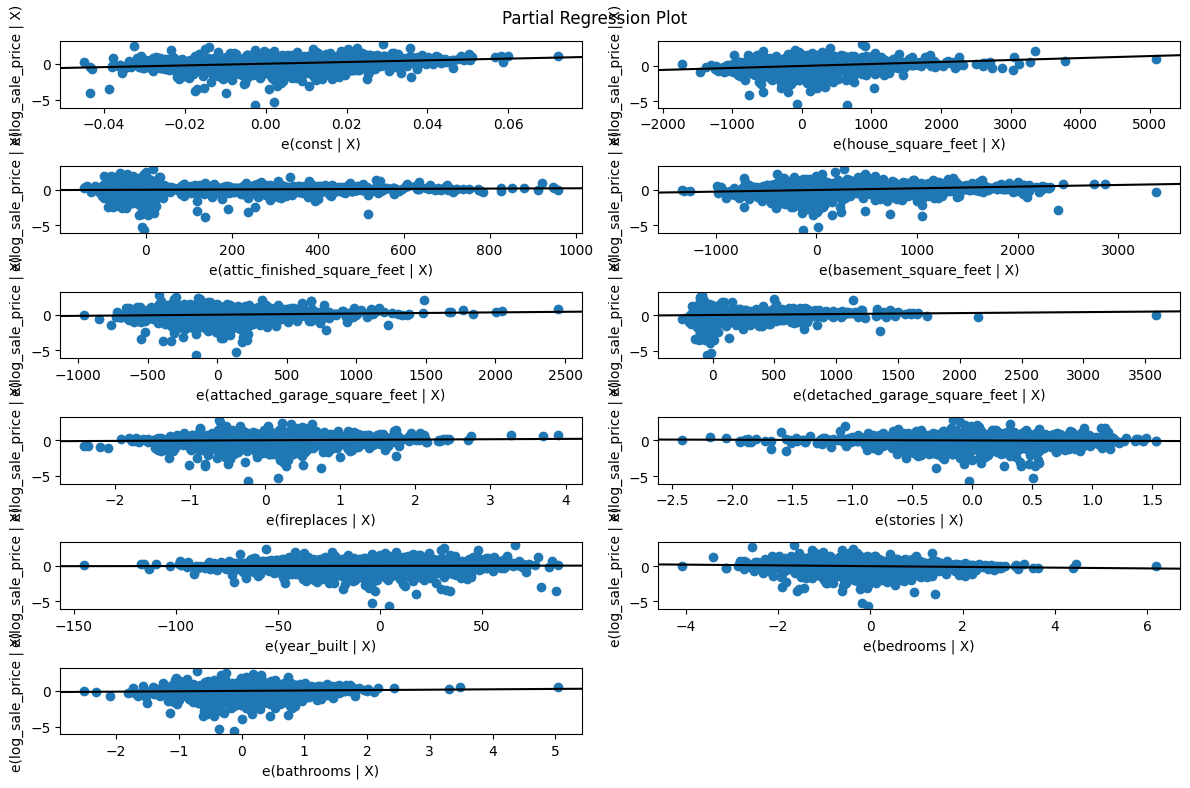

In [6]:
# Q5: No significant non-lineraities, maybe besides basement square feet
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_partregress_grid
import matplotlib.pyplot as plt
df['log_sale_price'] = np.log(df['sale_price'])
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
X = df_encoded.drop(columns=['sale_price', 'log_sale_price'])
y = df_encoded['log_sale_price']
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)
y = pd.to_numeric(y, errors='coerce')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)
print(f"Train RMSE: {rmse_train:.4f}, Train R²: {r2_train:.4f}")
print(f"Test RMSE: {rmse_test:.4f}, Test R²: {r2_test:.4f}")
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_train_sm = sm.add_constant(X_train_numeric)
ols_model = sm.OLS(y_train, X_train_sm).fit()
fig = plt.figure(figsize=(12, 8))
plot_partregress_grid(ols_model, fig=fig)
plt.tight_layout()
plt.show()

In [11]:
# Q6: We can see that 3 degrees of polynomials creates the largest test set R^2 for our original best model. It is up to .428 from .416
from sklearn.preprocessing import PolynomialFeatures

features = ['year_built', 'house_square_feet', 'attached_garage_square_feet', 'basement_square_feet']
X = df[features]
y = df['log_sale_price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# Loop through polynomial degrees for this subset
# -----------------------------
max_degree = 4  # you can adjust
results = []

for degree in range(1, max_degree+1):
    poly = PolynomialFeatures(degree=degree, interaction_only=False, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    r2_train = r2_score(y_train, y_train_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2_test = r2_score(y_test, y_test_pred)

    results.append({
        'degree': degree,
        'train_rmse': rmse_train,
        'train_r2': r2_train,
        'test_rmse': rmse_test,
        'test_r2': r2_test
    })

# Display results
results_df = pd.DataFrame(results)
print(results_df)

   degree  train_rmse  train_r2  test_rmse   test_r2
0       1    0.330722  0.398178   0.325401  0.417116
1       2    0.328556  0.406034   0.323894  0.422504
2       3    0.326496  0.413457   0.322236  0.428400
3       4    0.324549  0.420435   0.322736  0.426627


In [12]:
#Q7: In summary, I found it quite odd that the third model performed the best despite having fewer variables. This signifies the importance
# of having variable with generalizable predictive value over simply overfitting the testset with massive amounts of data. Also, I've gathered from
# thi lab and prior HW that it can be very useful to iterate through different levels of polynomial degrees to optimize a feature space.